# Practice 2.
##  Objectives:
1. Learn to clean data with pandas.

2. Do a simple Linear regression

## Aplication:
Data basse: Data set from the UCI Machine Learning Repository
(http://archive.ics.uci.edu/ml)
1.   Cars data: http://archive.ics.uci.edu/ml/datasets/Automobile.
- Predict **price** in dollars.

2. Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
- Predict **quality** (score between 0 and 10)


___________________________________

## First we load the Libraries
* Pandas: For dealing with tabulated data: excel + sql
* sklearn: Machine learning framework
* os: anciliary functions for dealing with the operating system

In [131]:
import pandas as pd
import os 

In [132]:
import matplotlib.pyplot as plt
import numpy as np
import sklearn

### Use the os library for generating the path to the file

In [133]:
File = "Bdcars.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\Users\Marcel\Uni\Master\MLEARN\MLEARN\Practicas\SecondPractice\Data\Bdcars.csv


### First rows of the file
**make, fuel-type, aspiration, num-of-doors, body-style, drive-wheels, engine-location, wheel-base, length, width, height, curb-weight, engine-type, num-of-cylinders, engine-size, fuel-system, bore, stroke, compression-ratio, horsepower, peak-rpm, city-mpg, highway-mpg, price**

alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495

alfa-romero,gas,std,two,convertible,rwd,front,88.60,168.80,64.10,48.80,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500

alfa-romero,gas,std,two,hatchback,rwd,front,94.50,171.20,65.50,52.40,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500

### Load the data by means of Pandas
- Note that the structure is a csv: Comma separated values
- The library recognizes the first line as the name of the columns
- Note the similarity with an *excel file*

#  See Appendix for  the meaning of the variables.

In [134]:
Data = pd.read_csv(Filename)
Data.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [32]:
print(f'Size of the database: {Data.shape} (rows X columns)')

Size of the database: (205, 24) (rows X columns)


## Next we get general information about the dataframe
## Dtype -> will allow to see which transformations should be done

In [33]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               205 non-null    str    
 1    fuel-type          205 non-null    str    
 2    aspiration         205 non-null    str    
 3    num-of-doors       205 non-null    str    
 4    body-style         205 non-null    str    
 5    drive-wheels       205 non-null    str    
 6    engine-location    205 non-null    str    
 7    wheel-base         205 non-null    float64
 8    length             205 non-null    float64
 9    width              205 non-null    float64
 10   height             205 non-null    float64
 11   curb-weight        205 non-null    int64  
 12   engine-type        205 non-null    str    
 13   num-of-cylinders   205 non-null    str    
 14   engine-size        205 non-null    int64  
 15   fuel-system        205 non-null    str    
 16   bore              

## First we clean the price feature
###  We erraise the unknowns '?'

In [135]:
Data =Data[Data[' price'] != '?']
Data[' price'] = Data[' price'].astype('float')
print('*'*30)
print('Shape of the data: ',Data.shape)
print('*'*30)
Data.info()

******************************
Shape of the data:  (201, 24)
******************************
<class 'pandas.DataFrame'>
Index: 201 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               201 non-null    str    
 1    fuel-type          201 non-null    str    
 2    aspiration         201 non-null    str    
 3    num-of-doors       201 non-null    str    
 4    body-style         201 non-null    str    
 5    drive-wheels       201 non-null    str    
 6    engine-location    201 non-null    str    
 7    wheel-base         201 non-null    float64
 8    length             201 non-null    float64
 9    width              201 non-null    float64
 10   height             201 non-null    float64
 11   curb-weight        201 non-null    int64  
 12   engine-type        201 non-null    str    
 13   num-of-cylinders   201 non-null    str    
 14   engine-size        201 non-nu

## Next we deal with the categorical data.
###  Get the unique data, observe the return object is a Numpy Array of objects (strings)
###  Note: This can be done in a more straight forward way, but  the idea is to get used with the basics of pandas.

In [136]:
NamesMake = Data[' make'].unique()
print(NamesMake)

<StringArray>
[  'alfa-romero',          'audi',           'bmw',     'chevrolet',
         'dodge',         'honda',         'isuzu',        'jaguar',
         'mazda', 'mercedes-benz',       'mercury',    'mitsubishi',
        'nissan',        'peugot',      'plymouth',       'porsche',
       'renault',          'saab',        'subaru',        'toyota',
    'volkswagen',         'volvo']
Length: 22, dtype: str


###  We create a code for each of the makes.
**NOTE**:  Categorical features, there is no order. 
**SOLUTION**: Will be given in decision trees.

### We use an implementation of 'dict comprehension' and '.map()'

In [137]:
CodeMake = list(range(len(NamesMake)))

MappingName2code = {key:float(val) for (key,val)  in zip(NamesMake,CodeMake)}
print(MappingName2code)

{'alfa-romero': 0.0, 'audi': 1.0, 'bmw': 2.0, 'chevrolet': 3.0, 'dodge': 4.0, 'honda': 5.0, 'isuzu': 6.0, 'jaguar': 7.0, 'mazda': 8.0, 'mercedes-benz': 9.0, 'mercury': 10.0, 'mitsubishi': 11.0, 'nissan': 12.0, 'peugot': 13.0, 'plymouth': 14.0, 'porsche': 15.0, 'renault': 16.0, 'saab': 17.0, 'subaru': 18.0, 'toyota': 19.0, 'volkswagen': 20.0, 'volvo': 21.0}


In [138]:
Data[' make'].map(MappingName2code)

0       0.0
1       0.0
2       0.0
3       1.0
4       1.0
       ... 
200    21.0
201    21.0
202    21.0
203    21.0
204    21.0
Name:  make, Length: 201, dtype: float64

In [139]:
Data[' make'] = Data[' make'].map(MappingName2code)
Data.T.head()

,0,1,2,3,4,5,6,7,8,10,...,195,196,197,198,199,200,201,202,203,204
make,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,...,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0,21.0
fuel-type,gas,gas,gas,gas,gas,gas,gas,gas,gas,gas,...,gas,gas,gas,gas,gas,gas,gas,gas,diesel,gas
aspiration,std,std,std,std,std,std,std,std,turbo,std,...,std,std,std,turbo,turbo,std,turbo,std,turbo,turbo
num-of-doors,two,two,two,four,four,two,four,four,four,two,...,four,four,four,four,four,four,four,four,four,four
body-style,convertible,convertible,hatchback,sedan,sedan,sedan,sedan,wagon,sedan,sedan,...,wagon,sedan,wagon,sedan,wagon,sedan,sedan,sedan,sedan,sedan


 ### Excercise: <font color='red'>Correct all the categorical fields </font>
 Note: In case there is an order, such as **num-of-doors** make a coding that follows the order.

<span style="color:green">First we will erase the numerical fields</span>

In [140]:
columns_correct = [" bore", " stroke", " peak-rpm", " horsepower"]
mask = (Data[columns_correct] != '?').all(axis=1)
Data = Data[mask]
Data[columns_correct] = Data[columns_correct].astype('float')
print('Shape of the data: ',Data.shape)
Data.info()

Shape of the data:  (195, 24)
<class 'pandas.DataFrame'>
Index: 195 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               195 non-null    float64
 1    fuel-type          195 non-null    str    
 2    aspiration         195 non-null    str    
 3    num-of-doors       195 non-null    str    
 4    body-style         195 non-null    str    
 5    drive-wheels       195 non-null    str    
 6    engine-location    195 non-null    str    
 7    wheel-base         195 non-null    float64
 8    length             195 non-null    float64
 9    width              195 non-null    float64
 10   height             195 non-null    float64
 11   curb-weight        195 non-null    int64  
 12   engine-type        195 non-null    str    
 13   num-of-cylinders   195 non-null    str    
 14   engine-size        195 non-null    int64  
 15   fuel-system        195 non-null    str    

<span style="color:green">Second we are going to correct the categorical fields with a order</span>

In [141]:
columns_correct = [" num-of-doors", " num-of-cylinders"]
mask = (Data[columns_correct] != '?').all(axis=1)
Data = Data[mask]
Data[" num-of-doors"] = Data[" num-of-doors"].map({
    "two": 2,
    "four": 4
}).astype(float)
Data[" num-of-cylinders"] = Data[" num-of-cylinders"].map({
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "eight": 8,
    "twelve": 12
}).astype(float)
print('Shape of the data: ',Data.shape)
Data.info()

Shape of the data:  (193, 24)
<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               193 non-null    float64
 1    fuel-type          193 non-null    str    
 2    aspiration         193 non-null    str    
 3    num-of-doors       193 non-null    float64
 4    body-style         193 non-null    str    
 5    drive-wheels       193 non-null    str    
 6    engine-location    193 non-null    str    
 7    wheel-base         193 non-null    float64
 8    length             193 non-null    float64
 9    width              193 non-null    float64
 10   height             193 non-null    float64
 11   curb-weight        193 non-null    int64  
 12   engine-type        193 non-null    str    
 13   num-of-cylinders   193 non-null    float64
 14   engine-size        193 non-null    int64  
 15   fuel-system        193 non-null    str    

<span style="color:green">Third we are going to correct the categorical fields with no order as before</span>

In [142]:
columns_correct = [" fuel-type", " aspiration", " body-style", " drive-wheels", " engine-location", " engine-type", " fuel-system"]
for col in columns_correct:
    unique_values = Data[col].unique()
    print(f"Unique values in {col}: {unique_values}")
    CodeMake = list(range(len(unique_values)))
    mapping = {key:float(val) for (key,val)  in zip(unique_values,CodeMake)}
    print(mapping)
    Data[col] = Data[col].map(mapping)

Unique values in  fuel-type: <StringArray>
['gas', 'diesel']
Length: 2, dtype: str
{'gas': 0.0, 'diesel': 1.0}
Unique values in  aspiration: <StringArray>
['std', 'turbo']
Length: 2, dtype: str
{'std': 0.0, 'turbo': 1.0}
Unique values in  body-style: <StringArray>
['convertible', 'hatchback', 'sedan', 'wagon', 'hardtop']
Length: 5, dtype: str
{'convertible': 0.0, 'hatchback': 1.0, 'sedan': 2.0, 'wagon': 3.0, 'hardtop': 4.0}
Unique values in  drive-wheels: <StringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str
{'rwd': 0.0, 'fwd': 1.0, '4wd': 2.0}
Unique values in  engine-location: <StringArray>
['front', 'rear']
Length: 2, dtype: str
{'front': 0.0, 'rear': 1.0}
Unique values in  engine-type: <StringArray>
['dohc', 'ohcv', 'ohc', 'l', 'ohcf']
Length: 5, dtype: str
{'dohc': 0.0, 'ohcv': 1.0, 'ohc': 2.0, 'l': 3.0, 'ohcf': 4.0}
Unique values in  fuel-system: <StringArray>
['mpfi', '2bbl', 'mfi', '1bbl', 'spfi', 'idi', 'spdi']
Length: 7, dtype: str
{'mpfi': 0.0, '2bbl': 1.0, 'mfi': 2.0, '

In [143]:
# Data[columns_correct].T.head()
Data.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               193 non-null    float64
 1    fuel-type          193 non-null    float64
 2    aspiration         193 non-null    float64
 3    num-of-doors       193 non-null    float64
 4    body-style         193 non-null    float64
 5    drive-wheels       193 non-null    float64
 6    engine-location    193 non-null    float64
 7    wheel-base         193 non-null    float64
 8    length             193 non-null    float64
 9    width              193 non-null    float64
 10   height             193 non-null    float64
 11   curb-weight        193 non-null    int64  
 12   engine-type        193 non-null    float64
 13   num-of-cylinders   193 non-null    float64
 14   engine-size        193 non-null    int64  
 15   fuel-system        193 non-null    float64
 16   bore               193 

 ### Next we will eraise the columns that have not been corrected.
 ### Also will correct the integers to floats.

In [144]:
Data.columns

Index([' make', ' fuel-type', ' aspiration', ' num-of-doors', ' body-style',
       ' drive-wheels', ' engine-location', ' wheel-base', ' length', ' width',
       ' height', ' curb-weight', ' engine-type', ' num-of-cylinders',
       ' engine-size', ' fuel-system', ' bore', ' stroke',
       ' compression-ratio', ' horsepower', ' peak-rpm', ' city-mpg',
       ' highway-mpg', ' price'],
      dtype='str')

In [145]:
TypeOfColumn = Data.dtypes
print(TypeOfColumn)

make                 float64
fuel-type            float64
aspiration           float64
num-of-doors         float64
body-style           float64
drive-wheels         float64
engine-location      float64
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type          float64
num-of-cylinders     float64
engine-size            int64
fuel-system          float64
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


In [146]:
cols2drop = list()
for col,dtype in zip(Data.columns,TypeOfColumn):
    print(f' Name of columns:{col}   \t||| Type of column: {dtype}')
    if dtype == 'object':
        cols2drop.append(col)

 Name of columns: make   	||| Type of column: float64
 Name of columns: fuel-type   	||| Type of column: float64
 Name of columns: aspiration   	||| Type of column: float64
 Name of columns: num-of-doors   	||| Type of column: float64
 Name of columns: body-style   	||| Type of column: float64
 Name of columns: drive-wheels   	||| Type of column: float64
 Name of columns: engine-location   	||| Type of column: float64
 Name of columns: wheel-base   	||| Type of column: float64
 Name of columns: length   	||| Type of column: float64
 Name of columns: width   	||| Type of column: float64
 Name of columns: height   	||| Type of column: float64
 Name of columns: curb-weight   	||| Type of column: int64
 Name of columns: engine-type   	||| Type of column: float64
 Name of columns: num-of-cylinders   	||| Type of column: float64
 Name of columns: engine-size   	||| Type of column: int64
 Name of columns: fuel-system   	||| Type of column: float64
 Name of columns: bore   	||| Type of column:

In [147]:
print(cols2drop)

[]


In [148]:
Data.drop(cols2drop,axis = 1).T

,0,1,2,3,4,5,6,7,8,10,...,195,196,197,198,199,200,201,202,203,204
make,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,2.0,...,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00,21.00
fuel-type,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
aspiration,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.0,...,0.00,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00
num-of-doors,2.00,2.00,2.00,4.00,4.00,2.00,4.00,4.00,4.00,2.0,...,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00,4.00
body-style,0.00,0.00,1.00,2.00,2.00,2.00,2.00,3.00,2.00,2.0,...,3.00,2.00,3.00,2.00,3.00,2.00,2.00,2.00,2.00,2.00
drive-wheels,0.00,0.00,0.00,1.00,2.00,1.00,1.00,1.00,1.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
engine-location,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
wheel-base,88.60,88.60,94.50,99.80,99.40,99.80,105.80,105.80,105.80,101.2,...,104.30,104.30,104.30,104.30,104.30,109.10,109.10,109.10,109.10,109.10
length,168.80,168.80,171.20,176.60,176.60,177.30,192.70,192.70,192.70,176.8,...,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80,188.80
width,64.10,64.10,65.50,66.20,66.40,66.30,71.40,71.40,71.40,64.8,...,67.20,67.20,67.20,67.20,67.20,68.90,68.80,68.90,68.90,68.90


In [149]:
Data = Data.drop(cols2drop,axis = 1)

<span style="color:green">We stay only with continious values (not categorical)</span>

In [150]:
# columns_correct = [" make", " bore", " stroke", " peak-rpm", " horsepower", " wheel-base", " length", " width", " height", " curb-weight", " engine-size", " compression-ratio", " city-mpg", " highway-mpg", " price"]
# Data = Data[columns_correct]
Data.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0    make               193 non-null    float64
 1    fuel-type          193 non-null    float64
 2    aspiration         193 non-null    float64
 3    num-of-doors       193 non-null    float64
 4    body-style         193 non-null    float64
 5    drive-wheels       193 non-null    float64
 6    engine-location    193 non-null    float64
 7    wheel-base         193 non-null    float64
 8    length             193 non-null    float64
 9    width              193 non-null    float64
 10   height             193 non-null    float64
 11   curb-weight        193 non-null    int64  
 12   engine-type        193 non-null    float64
 13   num-of-cylinders   193 non-null    float64
 14   engine-size        193 non-null    int64  
 15   fuel-system        193 non-null    float64
 16   bore               193 

## Before doing the linear regression analize the scatter plots


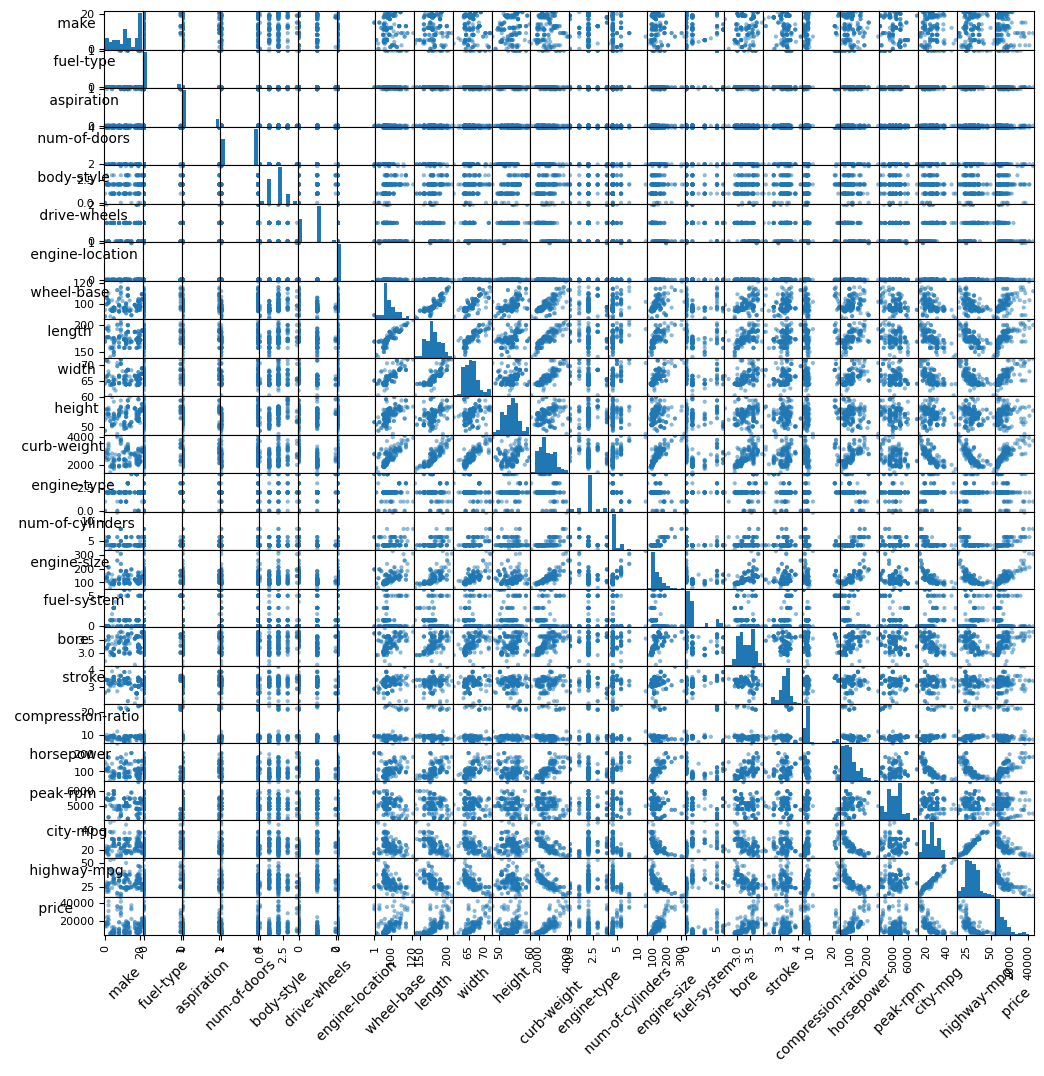

In [151]:
ax = pd.plotting.scatter_matrix(Data, figsize=(12,12))

for a in ax.ravel():
    a.set_xlabel(a.get_xlabel(), rotation=45)
    a.set_ylabel(a.get_ylabel(), rotation=0)

### Excercise 
1. <font color='red'> Relate price (target) to a subset of features </font>
2. <font color='red'> Relate  subset of features ' city-mpg',' length',' engine-size' between themselves </font>

* In theory we will explain why it is usefull, but first try to understand

1. <font color='green'> Relación del precio (target) con un subconjunto de características: </font>

Analizando el scatter plot matrix generado, podemos clasificar las variables según su relación con el precio:

**Variables con CORRELACIÓN FUERTE POSITIVA con el precio:**
*engine-size*: Muestra una relación muy clara y positiva. Los puntos forman una nube ascendente bien definida, indicando que a mayor tamaño del motor, mayor es el precio del vehículo.
*curb-weight*: Presenta una correlación positiva fuerte. La dispersión de puntos muestra una tendencia ascendente clara, donde coches más pesados tienden a ser más caros.
*horsepower*: Los puntos muestran una tendencia positiva pronunciada. Mayor potencia se asocia directamente con precios más elevados.
*width y length*: Ambas dimensiones muestran correlación positiva moderada-fuerte. Los puntos forman nubes ascendentes, aunque con algo más de dispersión que las anteriores.

**Variables con CORRELACIÓN NEGATIVA con el precio**
*city-mpg* y *highway-mpg*: Muestran correlación negativa moderada. Los puntos forman nubes descendentes, indicando que coches más eficientes en consumo tienden a ser más baratos (normalmente coches más pequeños y menos potentes).

**Variables con POCA o NINGUNA CORRELACIÓN:**
Variables categóricas codificadas (como *make*, *fuel-type*, *body-style*, etc.): En el scatter plot aparecen como líneas verticales o puntos agrupados en valores discretos sin mostrar ninguna tendencia clara con el precio. Esto es esperado, ya que al ser categorías codificadas numéricamente, no existe una relación lineal real. Por ejemplo, que una marca tenga código 5 y otra código 10 no significa que una sea "el doble" que la otra.
*compression-ratio*: Los puntos están muy dispersos sin formar ningún patrón claro, mostrando una correlación prácticamente nula con el precio.
*height*: Presenta una dispersión considerable de puntos sin una tendencia clara, indicando una correlación débil con el precio.

2. <font color='green'> Relación entre las características 'city-mpg', 'length', 'engine-size': </font>

Como podemos ver en el scatterplot realizado en la parte superior tenemos existe una relación fuerte entre engine-size y las otras dos variables, length y city-mpg, en relación a la length vemos que existe una correlacion fuerte, por la forma del scatterplot, donde cuando el valor de una aumenta el valor de la otra tambien, y tenemos una especie de curaa ascendente. Para city-mpg vemos de nuevo una correlación fuerte, aunque en este caso de forma negativa, cuando una aumenta la otra disminuye, y esto se puede ver de manera obvia en la curva del scatterplot.
La relación entre length y city-mpg si que es mas interesante de cara a trabajar con ellas, ya que como podemos ver en el scatterplot, los puntos estan más repartidos, mostrando así que existe menos relación entre ellos, por tanto una correlación baja (y negativa).

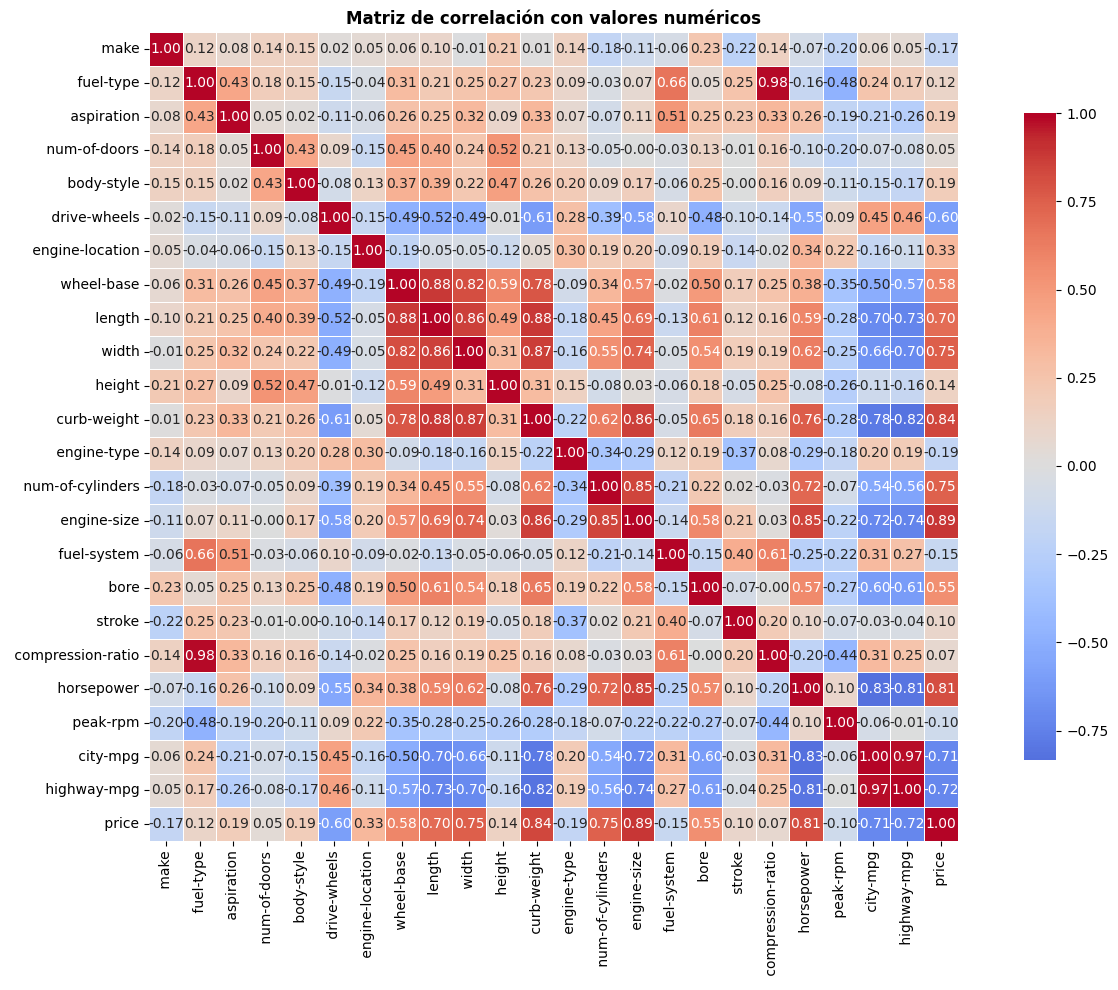

In [152]:
import seaborn as sns
plt.figure(figsize=(14, 10))
corr_matrix = Data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de correlación con valores numéricos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [153]:
print(Data.columns.values)

<StringArray>
[             ' make',         ' fuel-type',        ' aspiration',
      ' num-of-doors',        ' body-style',      ' drive-wheels',
   ' engine-location',        ' wheel-base',            ' length',
             ' width',            ' height',       ' curb-weight',
       ' engine-type',  ' num-of-cylinders',       ' engine-size',
       ' fuel-system',              ' bore',            ' stroke',
 ' compression-ratio',        ' horsepower',          ' peak-rpm',
          ' city-mpg',       ' highway-mpg',             ' price']
Length: 24, dtype: str


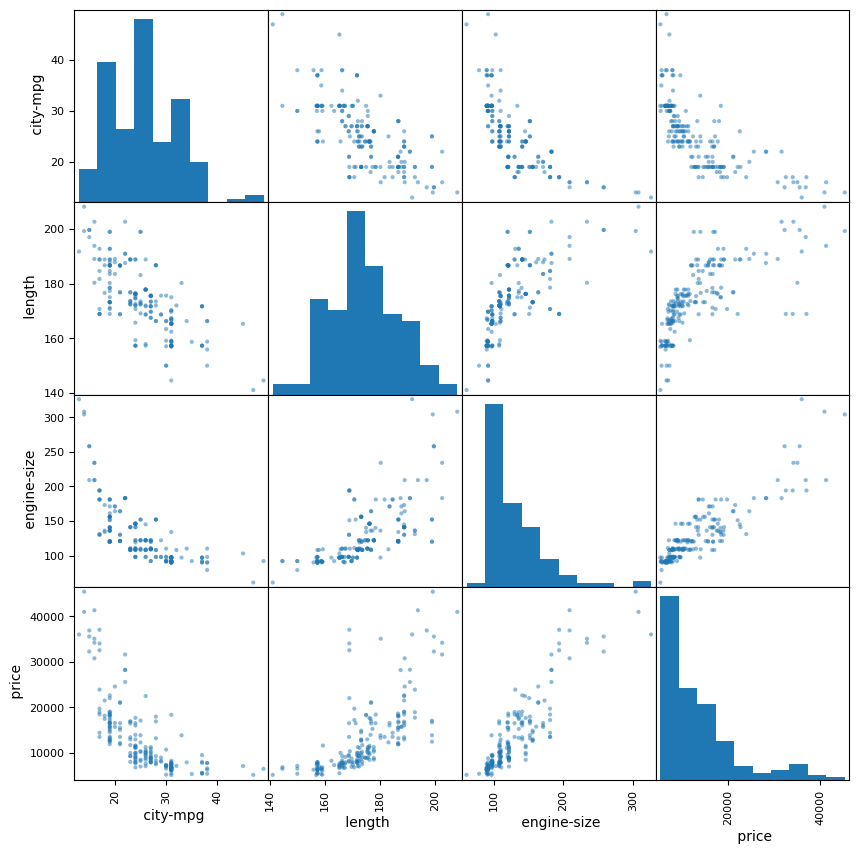

In [154]:
ax = pd.plotting.scatter_matrix(Data[[' city-mpg',' length',' engine-size',' price']],figsize = (10,10))

### Excercise 
1. <font color='red'> Explain in words, why correlation between input variables is bad, but with the output is good. </font>


1. <font color='green'> Explicación de por qué la correlación entre variables de entrada es mala, pero con la salida es buena </font>

La correlación entre variables de entrada es mala debido a una serie de puntos, primero que al tener variables correladas ambas aportan información similar, por tanto una acaba siendo redundante, en segundo lugar debido a este correlación los modelos tienen más dificultad para determinar los coeficientes y finalmente que dificulta el encontrar cuanto influye cada variable en el precio.

En cambio, la correlación entre variables de entrada i la salida es muy buena, debido a que prueba que la variable correlada es un buen predicador de la salida y ayuda ha realizar estimaciones, además de indicar que la variable contiene información útil. Por tanto las variables de entrada que esten correladas con la salida serán las más importantes.

 ## Now we will make a model that predicts the price given the features
 ###  Note that it will be a linear model. 
 
 * The scatter plot indicates that possibly we could use second order polynomials for fitting, but we have freedom for deciding the model.
 * There are other considerations for prefering a **linear model**.
 ###  First we create the database.

In [155]:
Input = Data[[' make', ' wheel-base' ,' length', ' width' ,' height', ' curb-weight',
 ' engine-size', ' compression-ratio', ' city-mpg', ' highway-mpg']]
Price = Data[[' price']]

### Next we estimate the parameters by **min squares**

In [156]:
from sklearn import linear_model
CarPrice = linear_model.LinearRegression()
CarPrice.fit (Input, Price)

print(CarPrice.coef_)
print(CarPrice.intercept_)

[[-140.63962856 -137.33578327  -40.70842587  696.97055214  397.94315481
     1.8924523   126.74274452  156.76539746 -428.78843721  261.12632032]]
[-51506.16714637]


In [157]:
print(Input.columns)

Index([' make', ' wheel-base', ' length', ' width', ' height', ' curb-weight',
       ' engine-size', ' compression-ratio', ' city-mpg', ' highway-mpg'],
      dtype='str')


In [158]:
df_car_coef = pd.DataFrame(CarPrice.coef_,columns = Input.columns)
df_car_coef

,make,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
0,-140.639629,-137.335783,-40.708426,696.970552,397.943155,1.892452,126.742745,156.765397,-428.788437,261.12632


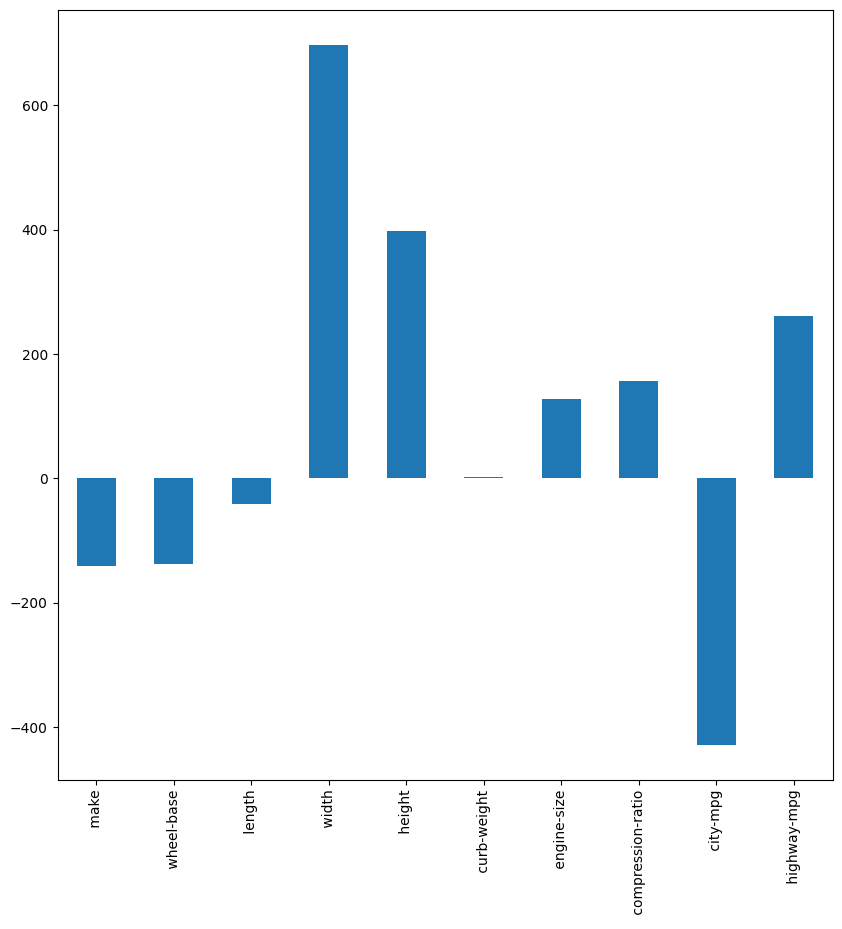

In [159]:
_ = df_car_coef.T.plot(kind = 'bar',figsize = (10,10),legend = False)


### Excercise 
1. <font color='red'> Explain in words, the meaning of each of the values of the weights. What sense do they have? </font>

2. <font color='red'> If collecting a database is expensive, what recommendation would you give? </font>


1. <font color='green'> Interpretación de los pesos y recomendaciones para bases de datos costosas </font>

Los pesos o coeficientes del modelo de regresión lineal representan la contribución individual de cada variable al precio del vehículo.
Cada peso indica cuánto cambia el precio (en dólares) cuando esa variable aumenta en una unidad, manteniendo todas las demás variables constantes.
El signo del peso indica la dirección de la relación:
- Positivo (+): A mayor valor de la variable, mayor precio
- Negativo (-): A mayor valor de la variable, menor precio

Observando el gráfico de barras generado:
curb-weight y engine-size: Probablemente tienen coeficientes positivos altos, lo que tiene sentido físico: coches más pesados y con motores más grandes son típicamente más caros y premium
city-mpg y highway-mpg: Probablemente tienen coeficientes negativos, lo cual es lógico: coches más eficientes en consumo suelen ser más pequeños y económicos.
make: Aunque aparece en el modelo, su interpretación es problemática porque es una variable categórica codificada arbitrariamente. El peso no tiene significado real.
width, length, height: Coeficientes que reflejan cómo las dimensiones afectan al precio.
compression-ratio: Probablemente un peso cercano a cero, reflejando su baja correlación con el precio.


2. <font color='green'> Recomendaciones si la recolección de datos es costosa </font>

En estos casos se debez optimizar qué variables medir. Realizar un estudio piloto pequeño para identificar las variables que tienen mayor correlación con el precio y mantenerlas, por otro lado eliminar o reducir las variables que tengan alta correlación ente si.
Otro metodo es el crear variables compuestas que capturen la información relevante, en este caso podriamos por ejemplo medir el tamaño general del vehículo combinando width, legth y height. 

## We will see how it works over the training database.
### Note that the correct way is to use a validation database, which we will see below

In [160]:
PredictedPrice  = CarPrice.predict(Input)

### Scatter plot. 
* Ideal relationship should be linear

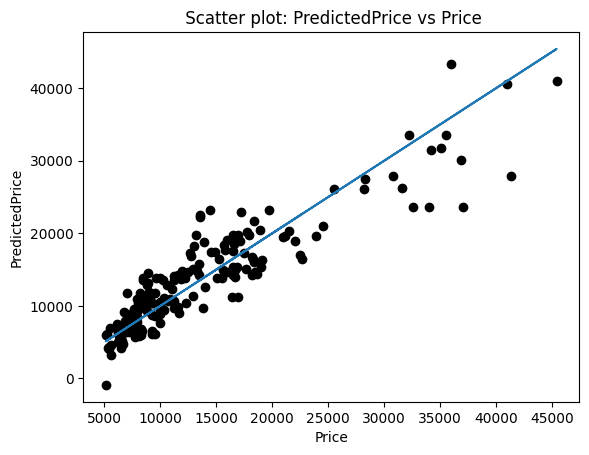

In [161]:
plt.scatter(Price, PredictedPrice,   color='black')
plt.title(' Scatter plot: PredictedPrice vs Price')
plt.plot(Price,Price)
plt.xlabel('Price')
plt.ylabel('PredictedPrice')
plt.show()

## Performance of the model on the training database

* Mean squared error:   
 $\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.$
* Explained variance ($R^2$):   
$R^2(y, \hat{y}) = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$

In [162]:
from sklearn.metrics import mean_squared_error
print (f'MSE = {mean_squared_error(Price, PredictedPrice):2.2f} ')
print (f'Root MSE = {np.sqrt(mean_squared_error(Price, PredictedPrice)):2.2f} ')

MSE = 10570057.80 
Root MSE = 3251.16 


In [163]:
from sklearn.metrics import r2_score
print (f'Explained Variance: $r^2$ = {r2_score(Price, PredictedPrice)*100.:2.2f} %')

Explained Variance: $r^2$ = 83.76 %


### Excercise 
1. <font color='red'> Explain in words, why r^2 is more usefull than MSE. </font>

1. <font color='green'> Explicación de por qué R² es más útil que MSE </font>

R² (Coeficiente de determinación) es más útil que MSE (Error cuadrático medio) por las siguientes razones:

Interpretabilidad y Escala Normalizada
R² está normalizado entre 0 y 1 (o 0% y 100%), lo que lo hace fácilmente interpretable: un R² = 0.83 significa que el modelo explica el 83% de la variabilidad de los datos.
MSE está en las unidades al cuadrado de la variable objetivo (en este caso, dólares²), lo que dificulta su interpretación directa. Por ejemplo, un MSE = 10,000,000 no indica inmediatamente si es bueno o malo.

Comparabilidad entre Modelos y Datasets
R² permite comparar modelos entre diferentes datasets o problemas, independientemente de la escala de la variable objetivo.
MSE depende completamente de la magnitud de los valores. Un MSE = 100 puede ser excelente si predecimos precios de 10,000-40,000 dólares, pero pésimo si predecimos valores de 100-500.

Contexto Relativo vs Absoluto
R² indica qué proporción de la varianza se explica comparada con un modelo baseline (la media), proporcionando contexto sobre la mejora del modelo.
MSE solo indica el error absoluto promedio, sin referencia a qué tan difícil es el problema de predicción.

Outliers
MSE es muy sensible a outliers. Debido a que MSE eleva al cuadrado los errores, los valores atípicos tienen un impacto desproporcionado
R² es más robusto. Aunque R² también se ve afectado por outliers, al estar normalizado respecto a la varianza total, un outlier afecta tanto al numerador como al denominador, su impacto relativo es menor y sigue siendo interpretable: si R² = 0.75, sabemos que explica el 75% de la varianza, independientemente de outliers.

##  Need for Cross-validation

###  Definition
Cross-validation is a statistical technique used in machine learning to evaluate how well a model generalizes to independent datasets.

1. It consists of dividing the training dataset into several parts, or folds, typically between 5 and 10 (See figure below).
<img src="EsquemaValidacioCreuada.png" width="60%">

2. One of the folds is reserved as a test set, while the rest are used to train the model. This process is repeated as many times as there are folds, so that each part of the dataset acts as a test set once.

3. Utility of validation:
   1. Detects overfitting, i.e., when a model adapts too much to the specific details of the training data and does not perform well with new examples.
   2. Through cross-validation, one can **better adjust the model parameters** to achieve a balance between fitting the training data and the ability to generalize.
   3. Allows creating more robust and reliable models, increasing confidence in the predictions made by these models in real-world situations.

In [164]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Set up 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Compute MSE using cross-validation (negative because sklearn uses negative MSE)
mse_scores = -cross_val_score(CarPrice, Input, Price, cv=kfold, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

# Compute R^2 using cross-validation
r2_scores = cross_val_score(CarPrice, Input, Price, cv=kfold, scoring='r2')

# Display results
print("Cross-Validation Results (5-Fold):")
print(f"MSE scores: {mse_scores}")
print(f"Mean MSE: {mse_scores.mean():.2f} (+/- {mse_scores.std():.2f})")
print(f"\nRMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")
print(f"\nR^2 scores: {r2_scores}")
print(f"Mean R^2: {r2_scores.mean()*100:.2f}% (+/- {r2_scores.std()*100:.2f}%)")

Cross-Validation Results (5-Fold):
MSE scores: [17730790.36819899 12355085.35594818 10734583.332349   11636279.40505596
 10035144.65455459]
Mean MSE: 12498376.62 (+/- 2732045.98)

RMSE scores: [4210.79450558 3514.98013593 3276.36739887 3411.19911542 3167.82964418]
Mean RMSE: 3516.23 (+/- 366.71)

R^2 scores: [0.84221754 0.5980051  0.86765469 0.77470281 0.78217261]
Mean R^2: 77.30% (+/- 9.43%)


 ### Excercise: 
1. <font color='red'> Explain in words, why the cross validation provides a more accurate estimate of what happens with unseen data.</font>
2. <font color='red'> Explain in words, the usefulness of having a confidence margin.</font>

 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


### Excercise: <font color='red'> Repeat the practice with the database **Wine Quality** target (**quality**) </font>

In [191]:
File = "winequality-red.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T
# Data.info()
# Data.describe().T.round(2)


Filename with path: 
 c:\Users\Marcel\Uni\Master\MLEARN\MLEARN\Practicas\SecondPractice\Data\winequality-red.csv


,0,1,2,3,4
fixed acidity,7.4000,7.8000,7.800,11.200,7.4000
volatile acidity,0.7000,0.8800,0.760,0.280,0.7000
citric acid,0.0000,0.0000,0.040,0.560,0.0000
residual sugar,1.9000,2.6000,2.300,1.900,1.9000
chlorides,0.0760,0.0980,0.092,0.075,0.0760
free sulfur dioxide,11.0000,25.0000,15.000,17.000,11.0000
total sulfur dioxide,34.0000,67.0000,54.000,60.000,34.0000
density,0.9978,0.9968,0.997,0.998,0.9978
pH,3.5100,3.2000,3.260,3.160,3.5100
sulphates,0.5600,0.6800,0.650,0.580,0.5600


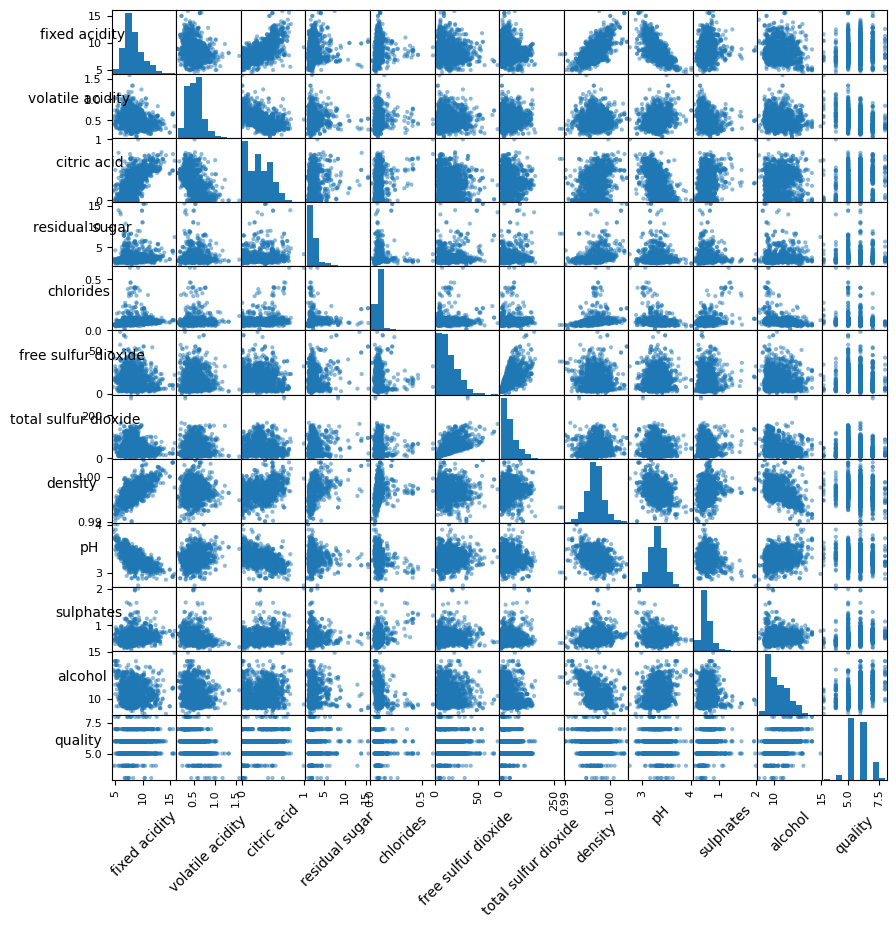

In [192]:
ax = pd.plotting.scatter_matrix(Data, figsize=(10,10))

for a in ax.ravel():
    a.set_xlabel(a.get_xlabel(), rotation=45)
    a.set_ylabel(a.get_ylabel(), rotation=0)

1. <font color='green'> Relación del precio (target) con un subconjunto de características: </font>

2. <font color='green'> Relación entre las características 'city-mpg', 'length', 'engine-size': </font>


In [202]:
Input = Data[['fixed acidity','volatile acidity','citric acid','residual sugar',
              'chlorides','free sulfur dioxide','total sulfur dioxide',
              'density','pH','sulphates','alcohol']]
Quality = Data[['quality']]
from sklearn import linear_model
WineQuality = linear_model.LinearRegression()
WineQuality.fit (Input, Quality)
print(WineQuality.coef_)
print(WineQuality.intercept_)


[[ 2.49905527e-02 -1.08359026e+00 -1.82563948e-01  1.63312698e-02
  -1.87422516e+00  4.36133331e-03 -3.26457970e-03 -1.78811638e+01
  -4.13653144e-01  9.16334413e-01  2.76197699e-01]]
[21.96520845]


In [203]:
df_wine_coef = pd.DataFrame(WineQuality.coef_,columns = Input.columns)
df_wine_coef


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.024991,-1.08359,-0.182564,0.016331,-1.874225,0.004361,-0.003265,-17.881164,-0.413653,0.916334,0.276198


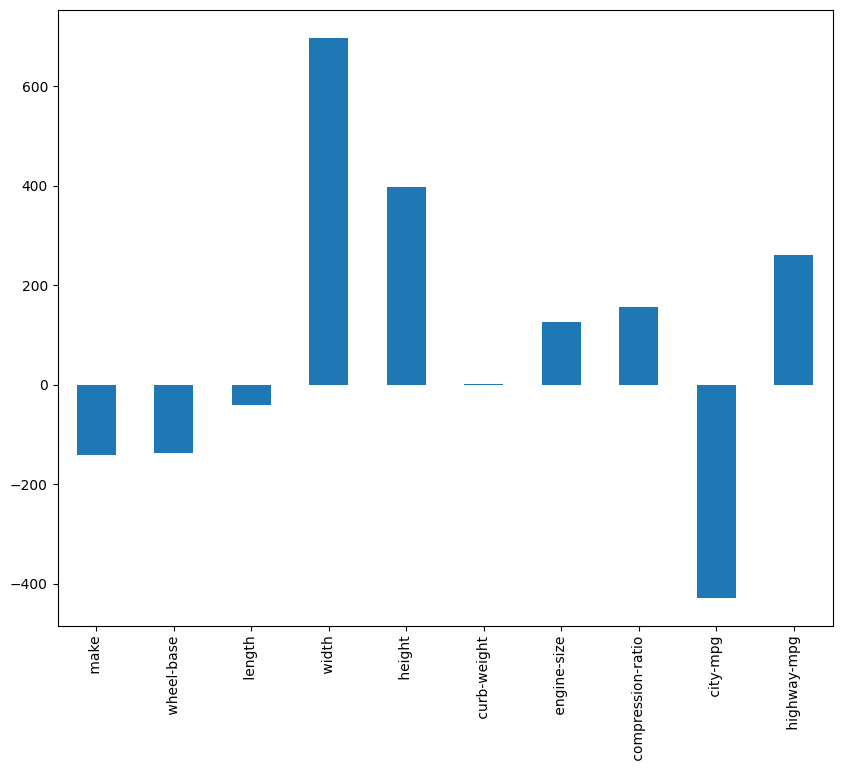

In [204]:
_ = df_car_coef.T.plot(kind = 'bar',figsize = (10,8),legend = False)

1. <font color='green'> Interpretación de los pesos y recomendaciones para bases de datos costosas </font>

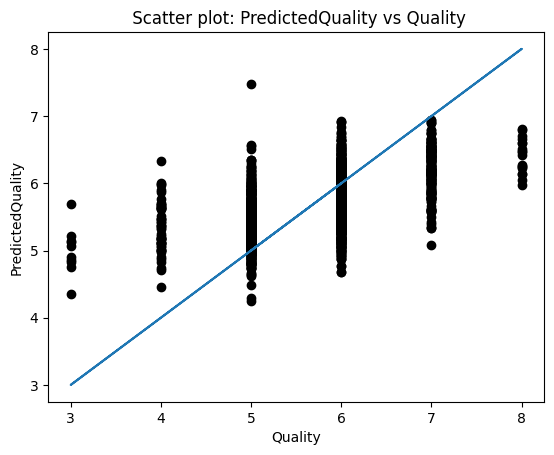

In [207]:
PredictedQuality  = WineQuality.predict(Input)
plt.scatter(Quality, PredictedQuality,   color='black')
plt.title(' Scatter plot: PredictedQuality vs Quality')
plt.plot(Quality,Quality)
plt.xlabel('Quality')
plt.ylabel('PredictedQuality')
plt.show()

In [208]:
from sklearn.metrics import mean_squared_error
print (f'MSE = {mean_squared_error(Quality, PredictedQuality):2.2f} ')
print (f'Root MSE = {np.sqrt(mean_squared_error(Quality, PredictedQuality)):2.2f} ')

MSE = 0.42 
Root MSE = 0.65 


In [210]:
from sklearn.metrics import r2_score
print (f'Explained Variance: $r^2$ = {r2_score(Quality, PredictedQuality)*100.:2.2f} %')

Explained Variance: $r^2$ = 36.06 %


## <font color='green'> Cross Validation </font>

In [211]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Set up 5-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Compute MSE using cross-validation (negative because sklearn uses negative MSE)
mse_scores = -cross_val_score(WineQuality, Input, Quality, cv=kfold, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(mse_scores)

# Compute R^2 using cross-validation
r2_scores = cross_val_score(WineQuality, Input, Quality, cv=kfold, scoring='r2')

# Display results
print("Cross-Validation Results (5-Fold):")
print(f"MSE scores: {mse_scores}")
print(f"Mean MSE: {mse_scores.mean():.2f} (+/- {mse_scores.std():.2f})")
print(f"\nRMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")
print(f"\nR^2 scores: {r2_scores}")
print(f"Mean R^2: {r2_scores.mean()*100:.2f}% (+/- {r2_scores.std()*100:.2f}%)")

Cross-Validation Results (5-Fold):
MSE scores: [0.39002514 0.46758029 0.48341328 0.45494133 0.34785364]
Mean MSE: 0.43 (+/- 0.05)

RMSE scores: [0.62451993 0.68379842 0.69527929 0.67449339 0.58979118]
Mean RMSE: 0.65 (+/- 0.04)

R^2 scores: [0.40318034 0.27207156 0.27288121 0.33727873 0.42666126]
Mean R^2: 34.24% (+/- 6.42%)


## Appendix:
### Description of the variables
 1. make: The name of the produces of the car (a factor).
 - alfa-romero, audi, bmw, chevrolet, dodge, honda,  isuzu, jaguar, mazda, mercedes-benz, mercury,mitsubishi, nissan, peugot, plymouth, porsche,renault, saab, subaru, toyota, volkswagen, volvo
 
2. fuel-type: The type of fuel used by the car, either diesel or gas (a factor).
 - diesel, gas.
3. aspiration:	Type of aspiration of fuel in the motor
- std, turbo.
4. num-of-doors: The number of passenger doors, either two or four (a factor).
 - four, two.
5. body-styleThe type of the car (a factor).
- hardtop, wagon, sedan, hatchback, convertible.
6. drive-wheels: The wheels powered by the engine (a factor).
- 4wd, fwd, rwd.
7. engine-location: The location in the car of the engine (a factor).
- front, rear.
8. wheel-base: The distance between the centers of the front and rear wheels in inches (numeric).	
- continuous from 86.6 120.9.
9. length: The length of the body of the car in inches (numeric).
- continuous from 141.1 to 208.1.
10. width: The width of the body of the car in inches (numeric).
- continuous from 60.3 to 72.3.
11. height: The height of the car in inches (numeric).
- continuous from 47.8 to 59.8.
12. curb-weight: The total weight in pounds of a vehicle with standard equipment and a full tank of fuel, but with no passengers or cargo (numeric).	 
- continuous from 1488 to 4066.
13. engine-type: Mechanical Feature  (numeric).	 
- dohc, dohcv, l, ohc, ohcf, ohcv, rotor.
14. num-of-cylinders:: Mechanical Feature  (a factor).
- eight, five, four, six, three, twelve, two.
15. engine-size: The volume swept by all the pistons inside the cylinders in cubic inches (numeric).
 - continuous from 61 to 326.
16. fuel-system: Mechanical Feature  (a factor).
- 1bbl, 2bbl, 4bbl, idi, mfi, mpfi, spdi, spfi.
17. bore: Mechanical Feature  (numeric).	
- continuous from 2.54 to 3.94.
18. stroke: Mechanical Feature  (numeric).	 
- continuous from 2.07 to 4.17.
19. compression-ratio: Mechanical Feature  (numeric).	  
- continuous from 7 to 23.
20. horsepower: The power of the engine in horsepowers (numeric).	
- continuous from 48 to 288.
21. peak-rpm: The top speed of the engine in rounds-per-minute (numeric).
- continuous from 4150 to 6600.
22. city-mpg: The fuel consumption of the car in city driving conditions, measured as miles per gallon of fuel (numeric).	 
- continuous from 13 to 49.
23. highway-mpg: The fuel consumption of the car in highway driving conditions, measured as miles per gallon of fuel (numeric).	 
- continuous from 16 to 54.
24. price: The retail price of the car in US Dollars (numeric).	
- continuous from 5118 to 45400.

    

## Description of variables: Wine  quality
### Input variables (based on physicochemical tests):
1. fixed acidity
2. volatile acidity
3. citric acid
4. residual sugar
5. chlorides
6. free sulfur dioxide
7. total sulfur dioxide
8. density
9. pH
10. sulphates
11. alcohol
Output variable (based on sensory data): 
12. quality (score between 0 and 10)
